# SONICS Dataset Analysis - Master's Thesis Preparation
Ten notatnik generuje główne statystyki, tabele i wykresy potrzebne do opisu zbioru danych w pracy magisterskiej.

## 1. Setup & Inicjalizacja

In [1]:
!uv pip install polars
!uv pip install scikit-learn

Audited 1 package in 18ms
Audited 1 package in 16ms


In [2]:
import json
from pathlib import Path
import soundfile as sf
import polars
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from concurrent.futures import ThreadPoolExecutor

# Konfiguracja stylu wykresów do pracy dyplomowej
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

In [3]:
# Ścieżki
SONICS_BASE_PATH = Path("/net/people/plgrid/plgjedrzejkusnierz/scratch/data/Sonics")
DATA_BASE_PATH = SONICS_BASE_PATH / "all_data"
DATA = SONICS_BASE_PATH / "all_data_16k_mono"
METADATA = DATA_BASE_PATH / "metadata.json"

embedds_path = SONICS_BASE_PATH / "preprocessed_16k_mono"
mert_path = embedds_path / "mert"
w2v_path = embedds_path / "wav2vec"

print(f"Dane audio: {DATA}")
print(f"Metadane: {METADATA}")

Dane audio: /net/people/plgrid/plgjedrzejkusnierz/scratch/data/Sonics/all_data_16k_mono
Metadane: /net/people/plgrid/plgjedrzejkusnierz/scratch/data/Sonics/all_data/metadata.json


In [4]:
# Wczytanie metadanych plików pobranych na dysk
with open(METADATA, 'r') as f:
    metadata = json.load(f)

df_meta = pd.DataFrame(metadata)
df_meta['duration'] = pd.to_numeric(df_meta['duration'], errors='coerce')
print(f"Załadowano {len(df_meta)} rekordów z metadata.json")

Załadowano 93221 rekordów z metadata.json


In [5]:
# Wyliczanie RZECZYWISTEJ długości pobranych nagrań (Soundfile)
all_files = list(DATA.glob("*.flac"))

def get_duration(filepath):
    try:
        info = sf.info(str(filepath))
        return filepath.name, info.duration
    except Exception:
        return filepath.name, 0.0

print(f"Rozpoczynam liczenie dla {len(all_files)} plików (to potrwa ok. minuty)...")

durations = []
with ThreadPoolExecutor(max_workers=16) as executor:
    results = executor.map(get_duration, all_files)
    for res in results:
        durations.append(res)

df_real_durations = pd.DataFrame(durations, columns=["filename", "real_duration_sec"])

# Dołączenie rzeczywistych długości do tabeli głównej
if 'real_duration_sec' not in df_meta.columns:
    df_meta = pd.merge(df_meta, df_real_durations, on="filename", how="left")
    
# Obliczenie sumarycznego czasu trwania
total_sec_bonafide = df_meta[df_meta['spoof'] == 'bonafide']['real_duration_sec'].sum()
total_sec_deepfake = df_meta[df_meta['spoof'] == 'deepfake']['real_duration_sec'].sum()

print("-" * 40)
print(f"Całkowity czas Bonafide: {total_sec_bonafide / 3600:.2f} godzin")
print(f"Całkowity czas Deepfake: {total_sec_deepfake / 3600:.2f} godzin")
print(f"ŁĄCZNIE: {(total_sec_bonafide + total_sec_deepfake) / 3600:.2f} godzin")

Rozpoczynam liczenie dla 93215 plików (to potrwa ok. minuty)...
----------------------------------------
Całkowity czas Bonafide: 2709.34 godzin
Całkowity czas Deepfake: 1969.27 godzin
ŁĄCZNIE: 4678.62 godzin


## 2. Statystyki Zbioru i Stratyfikacja (Dane do tabeli)
Generuje liczności klas dla podzbiorów Train / Valid / Test.

--- Stratyfikacja podzbiorów (Ostatecznie Pobrane Dane) ---

[TRAIN SET] -> 64055 próbek łącznie
  - Deepfake: 34023 (53.1%)
  - Bonafide: 30032 (46.9%)

[VALID SET] -> 4261 próbek łącznie
  - Deepfake: 2273 (53.3%)
  - Bonafide: 1988 (46.7%)

[TEST SET] -> 24905 próbek łącznie
  - Deepfake: 12778 (51.3%)
  - Bonafide: 12127 (48.7%)


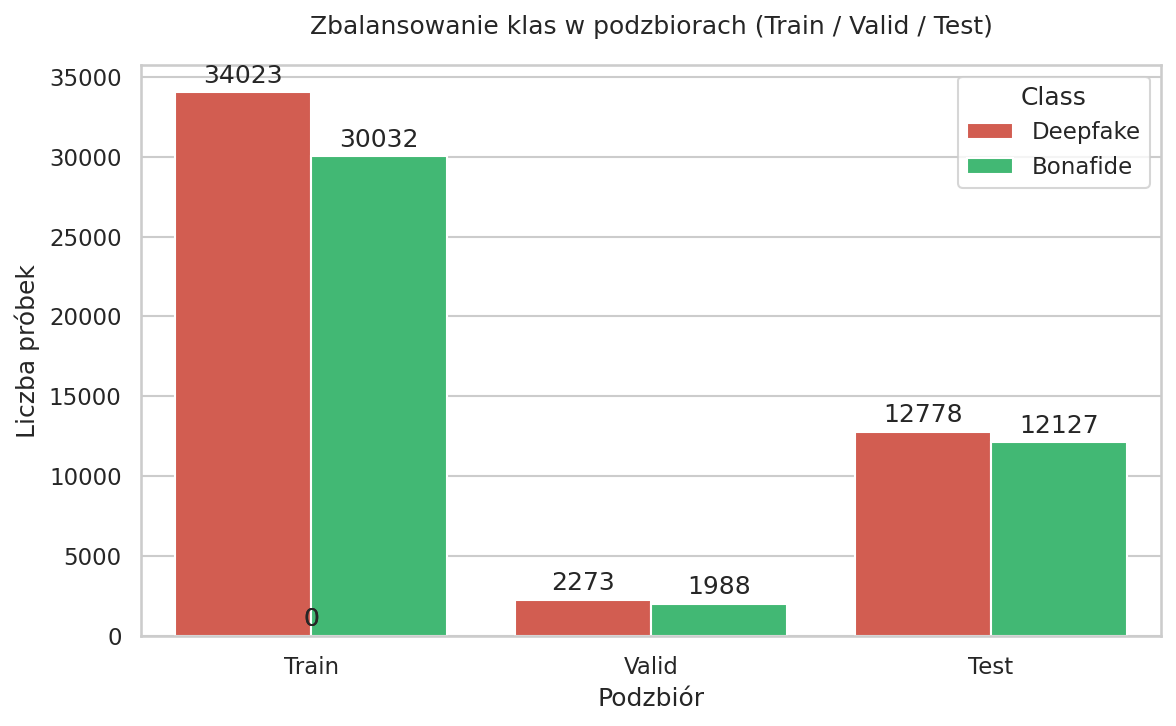

In [9]:
print("--- Stratyfikacja podzbiorów (Ostatecznie Pobrane Dane) ---")
splits_data = []

for split_name in ['train', 'valid', 'test']:
    df_split = df_meta[df_meta['set'] == split_name]
    total = len(df_split)
    print(f"\n[{split_name.upper()} SET] -> {total} próbek łącznie")
    
    if total > 0 and 'spoof' in df_split.columns:
        counts = df_split['spoof'].value_counts()
        for k, v in counts.items():
            if k != "":
                print(f"  - {k.capitalize()}: {v} ({v/total*100:.1f}%)")
                splits_data.append({"Split": split_name.capitalize(), "Class": k.capitalize(), "Count": v})

# Wykres zbalansowania
if splits_data:
    df_splits = pd.DataFrame(splits_data)
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=df_splits, x="Split", y="Count", hue="Class", palette={"Bonafide": "#2ecc71", "Deepfake": "#e74c3c"})
    plt.title("Zbalansowanie klas w podzbiorach (Train / Valid / Test)", pad=15)
    plt.ylabel("Liczba próbek")
    plt.xlabel("Podzbiór")
    
    # Wartości nad słupkami
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points')
    
    plt.tight_layout()
    plt.show()

## 3. Analiza Źródeł (Content Analysis)
Rozkład algorytmów użytych do wygenerowania Deepfake'ów.

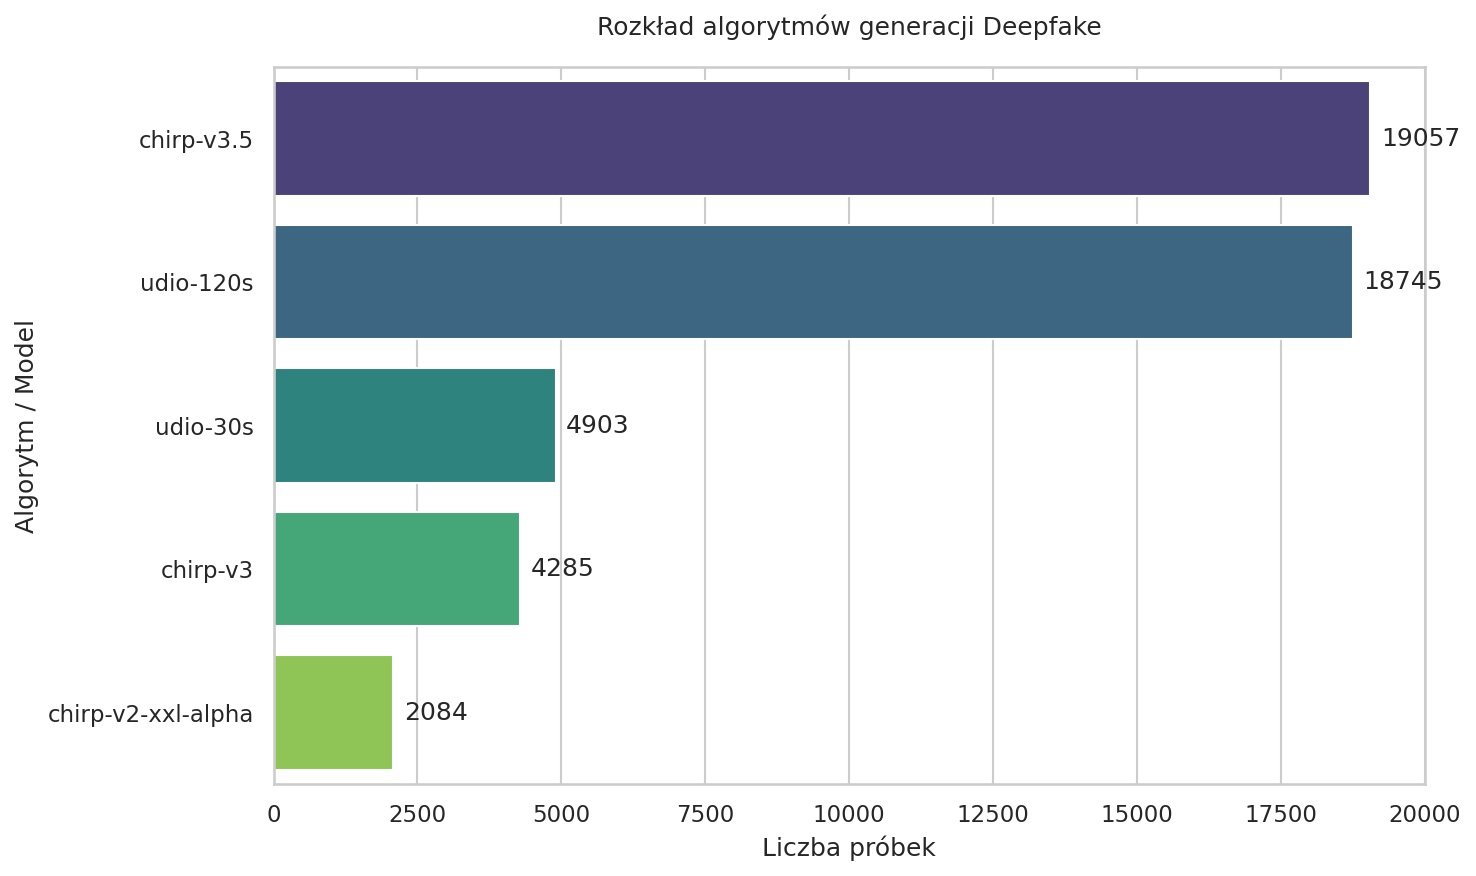

In [7]:
df_deepfake = df_meta[df_meta['spoof'] == 'deepfake'].copy()

# Oczyszczenie pustych wartości
df_deepfake['algorithm'] = df_deepfake['algorithm'].replace('', 'Nieznany')
algo_counts = df_deepfake['algorithm'].value_counts()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=algo_counts.values, y=algo_counts.index, hue=algo_counts.index, legend=False, palette="viridis")
plt.title("Rozkład algorytmów generacji Deepfake", pad=15)
plt.xlabel("Liczba próbek")
plt.ylabel("Algorytm / Model")

for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}", (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

## 4. Parametry Audio (Rozkład Długości)
Podwójny histogram pokazujący rozkład długości w sekundach (skala logarytmiczna dla czytelności).

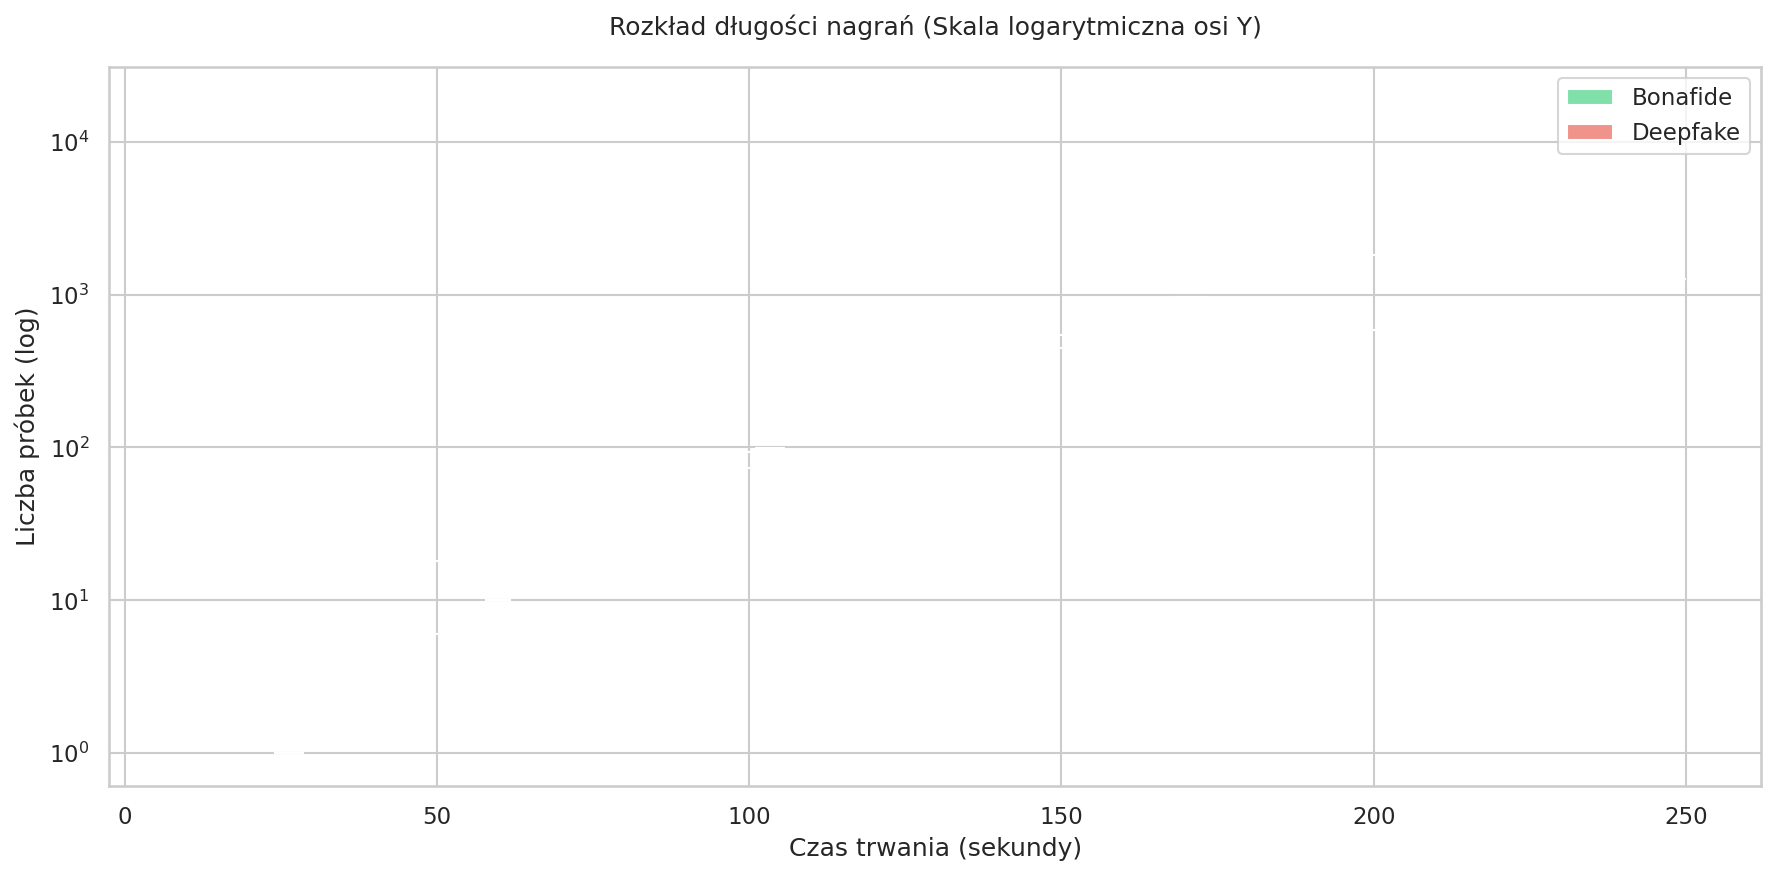

In [8]:
plt.figure(figsize=(12, 6))

# Filtrujemy outliery dla czytelności wykresu (np. nagrania > 300 sekund jeśli są)
max_dur = 250
data_b = df_meta[(df_meta['spoof'] == 'bonafide') & (df_meta['real_duration_sec'] <= max_dur)]['real_duration_sec']
data_d = df_meta[(df_meta['spoof'] == 'deepfake') & (df_meta['real_duration_sec'] <= max_dur)]['real_duration_sec']

sns.histplot(data_b, bins=50, color="#2ecc71", label="Bonafide", alpha=0.6, log_scale=(False, True))
sns.histplot(data_d, bins=50, color="#e74c3c", label="Deepfake", alpha=0.6, log_scale=(False, True))

plt.title("Rozkład długości nagrań (Skala logarytmiczna osi Y)", pad=15)
plt.xlabel("Czas trwania (sekundy)")
plt.ylabel("Liczba próbek (log)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Embedingi & EDA (Przygotowanie)
Ta sekcja posłuży do analizy przestrzeni wektorowej (MERT / Wav2Vec2) i testu Data Leakage.

In [ ]:
# Weryfikacja czy embedingi są już wygenerowane
mert_files = sorted(list(mert_path.glob("*.npy")))
w2v_files = sorted(list(w2v_path.glob("*.npy")))

print(f"Znaleziono {len(mert_files)} plików z cechami MERT")
print(f"Znaleziono {len(w2v_files)} plików z cechami Wav2Vec2")

# Tutaj później załadujemy np. 1000 losowych wektorów MERT do df_features

In [ ]:
def plot_tsne(features, labels, title="t-SNE wizualizacja embeddingów"):
    '''Funkcja przygotowana do wizualizacji cech gdy pliki .npy będą gotowe.'''
    print("Redukcja wymiarowości t-SNE...")
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(features)
    
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=features_2d[:, 0], y=features_2d[:, 1], hue=labels, palette={"bonafide": "#2ecc71", "deepfake": "#e74c3c"}, s=15, alpha=0.7)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Przykładowe użycie (gdy będą dane):
# plot_tsne(features_matrix, labels_list, title="MERT Embeddings (t-SNE)")

In [ ]:
def data_leakage_check(df_features, label_col='spoof'):
    '''Sprawdza czy istnieją pojedyncze cechy z absurdalnie dużą różnicą średnich między klasami.'''
    # Oddzielamy cechy od etykiet
    feature_cols = [c for c in df_features.columns if c != label_col]
    
    means_bona = df_features[df_features[label_col] == 'bonafide'][feature_cols].mean()
    means_fake = df_features[df_features[label_col] == 'deepfake'][feature_cols].mean()
    
    diffs = (means_bona - means_fake).abs().sort_values(ascending=False)
    
    print("Największe różnice średnich na pojedynczych cechach (Top 5):")
    print(diffs.head(5))
    
    if diffs.iloc[0] > 10.0:
        print("UWAGA: Potencjalny wyciek danych (Data Leakage) na najważniejszej cesze!")
    else:
        print("Brak oczywistych anomalii na poziomie pojedynczych wymiarów.")